In [96]:
import numpy as np
import pandas as pd

import plotly.express as px
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

import plotly.io as pio
pio.renderers.default = "iframe"

In [97]:
data = pd.read_csv("advertising.csv")

In [98]:
data.head(10)

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
5,8.7,48.9,75.0,7.2
6,57.5,32.8,23.5,11.8
7,120.2,19.6,11.6,13.2
8,8.6,2.1,1.0,4.8
9,199.8,2.6,21.2,15.6


In [99]:
data.shape

(200, 4)

In [100]:
fig = px.scatter(data, x="TV", y="Sales")
fig.show()

In [101]:
fig = px.scatter(data, x="Radio", y="Sales")
fig.show()

In [102]:
fig = px.scatter(data, x="Newspaper", y="Sales")
fig.show()

In [103]:
df = data.copy()

X = df.drop(columns=["Sales"])
y = df.pop("Sales")

print(X.head())
print(y.head())

train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.2)

      TV  Radio  Newspaper
0  230.1   37.8       69.2
1   44.5   39.3       45.1
2   17.2   45.9       69.3
3  151.5   41.3       58.5
4  180.8   10.8       58.4
0    22.1
1    10.4
2    12.0
3    16.5
4    17.9
Name: Sales, dtype: float64


In [104]:
#fig = px.pie(train_X, title="advertising platforms")

#df_long = pd.melt(df, value_vars=['TV', 'Radio', 'Newspaper'], var_name='Ad campaign budgets', value_name='Budget_USD')

#fig = px.pie(df_long)

import plotly.graph_objects as go

fig = go.Figure(data=[go.Pie(
    labels=X.columns,          # Uses the column names directly
    values=X.iloc[0].values    # Uses the numbers from the first row
)])

fig.show()

In [105]:
model = LinearRegression()

In [106]:
model.fit(X, y)

print(model.coef_)
print(model.intercept_)

[0.05444578 0.10700123 0.00033566]
4.625124078808653


In [107]:
#X_line = np.linspace(train_X.min(), train_X.max(), 100).reshape(-1, 1)
#y_line_pred = model.predict(X_line)

#plt.plot(X_line, y_line_pred, color='k')
#plt.show()

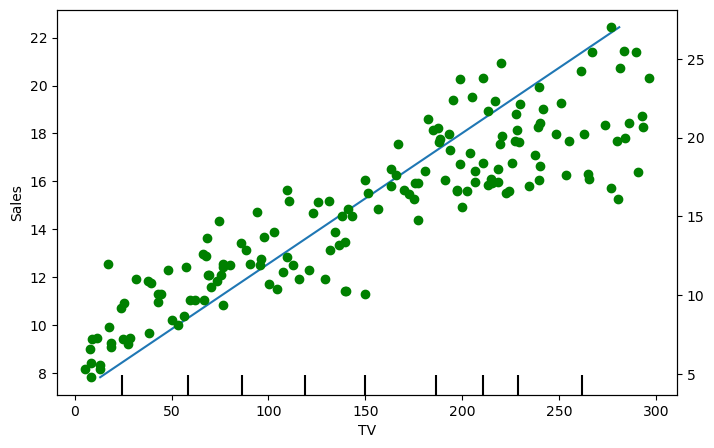

In [108]:
from sklearn.inspection import PartialDependenceDisplay

fig, ax = plt.subplots(figsize=(8, 5))

display = PartialDependenceDisplay.from_estimator(model, X, features=[0], ax=ax)

for ax_row in display.axes_:
    for ax in ax_row:
        if ax.get_ylabel():  # Check if the axis has a y label enabled
            ax.set_ylabel("Sales")

#ax.set_ylabel("Sales")

ax2 = ax.twinx()
ax2.scatter(train_X["TV"], train_y, color='g')

plt.show()

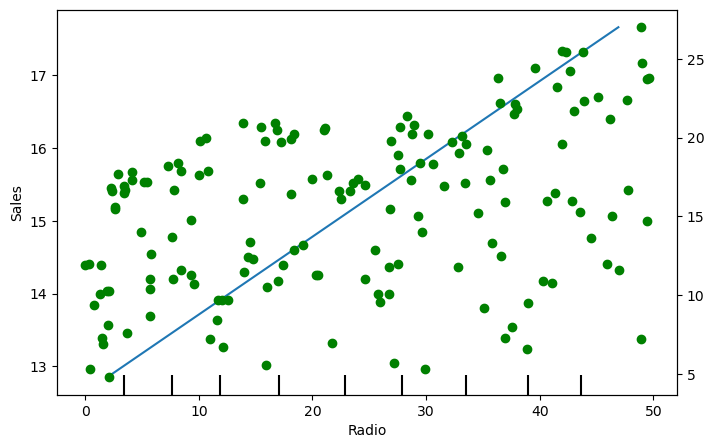

In [109]:
fig, ax = plt.subplots(figsize=(8, 5))

display = PartialDependenceDisplay.from_estimator(model, X, features=[1], ax=ax)

for ax_row in display.axes_:
    for ax in ax_row:
        if ax.get_ylabel():  # Check if the axis has a y label enabled
            ax.set_ylabel("Sales")

ax2 = ax.twinx()
ax2.scatter(train_X["Radio"], train_y, color='g')

plt.show()

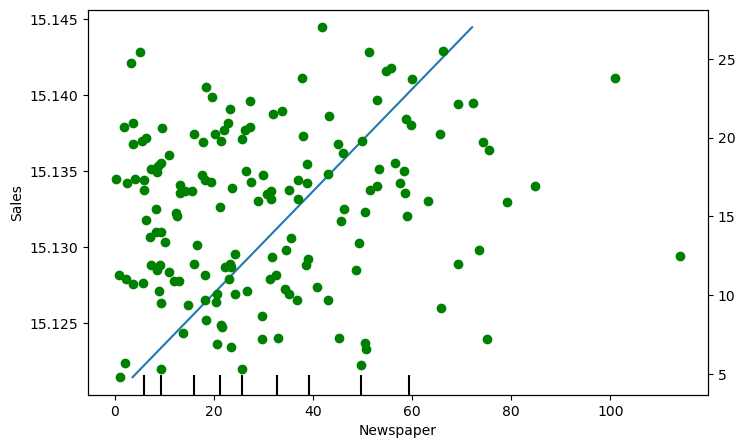

In [110]:
fig, ax = plt.subplots(figsize=(8, 5))

display = PartialDependenceDisplay.from_estimator(model, X, features=[2], ax=ax)

for ax_row in display.axes_:
    for ax in ax_row:
        if ax.get_ylabel():  # Check if the axis has a y label enabled
            ax.set_ylabel("Sales")

ax2 = ax.twinx()
ax2.scatter(train_X["Newspaper"], train_y, color='g')

plt.show()

In [111]:
train_accuracy = model.score(train_X, train_y)
test_accuracy = model.score(test_X, test_y)

print(train_accuracy)
print(test_accuracy)

0.9063923476945813
0.8851367797835767


In [112]:
predict_set = test_X.head(n=100)

print("predict set:\n\n", predict_set)

print("\ny_test:\n\n", test_y.head(n=100))

y_predicted = model.predict(predict_set)

print("\ny_predicted:\n\n", y_predicted)

predict set:

         TV  Radio  Newspaper
21   237.4    5.1       23.5
75    16.9   43.7       89.4
50   199.8    3.1       34.6
139  184.9   43.9        1.7
196   94.2    4.9        8.1
46    89.7    9.9       35.7
115   75.1   35.0       52.7
32    97.2    1.5       30.0
116  139.2   14.3       25.6
153  171.3   39.7       37.7
25   262.9    3.5       19.5
192   17.2    4.1       31.6
155    4.1   11.6        5.7
164  117.2   14.7        5.4
99   135.2   41.7       45.9
171  164.5   20.9       47.4
77   120.5   28.5       14.2
92   217.7   33.5       59.0
172   19.6   20.1       17.0
113  209.6   20.6       10.7
44    25.1   25.7       43.3
134   36.9   38.6       65.6
28   248.8   27.1       22.9
191   75.5   10.8        6.0
199  232.1    8.6        8.7
7    120.2   19.6       11.6
1     44.5   39.3       45.1
104  238.2   34.3        5.3
19   147.3   23.9       19.1
114   78.2   46.8       34.5
72    26.8   33.0       19.3
130    0.7   39.6        8.7
100  222.4    4.3       49.8

In [113]:
train_X.shape

(160, 3)

In [114]:
test_X.shape

(40, 3)